# <p style="font-size:100%; text-align:left; color:#444444;">Analysis on Avian Influenza (Bird Flu) in migratory Wild Birds in Ireland</p>

![Wild Birds](img/wild-geese-pixabay_1149609_1920.jpeg "Word Cloud")

---
# <p style="font-size:100%; text-align:left; color:#444444;">Contents:</p>

* [1. Introduction](#1)
* [2. EDA](#2)
    * [2.1 Percentage of captured birds with avian flu](#2.1)
    * [2.2 Counties with the highest Bird Flu occurences](#2.2)
    * [2.3 Locations with the highest number of infected birds](#2.3)
    * [2.4 Monthly ](#2.4)
    * [2.5 Yearly ](#2.5)
* [3. GeoPandas](#3)
    * [3.1 Ordnance Survey Ireland - Ireland’s National Mapping Agency](#3.1)
* [4. Evaluation](#4)
    * [4.1 Normalized Gini Coefficient](#4.1)
* [5. Conclusion](#5)

<a id="1"></a>
# <p style="font-size:100%; text-align:left; color:#444444;">1- Introduction</p>

<img title="Department of Agriculture, Food and the Marine" src="img/department-of-agriculture-food-and-the-marine.png" alt="Department of Agriculture, Food and the Marine" align="right" style='height:150px; padding: 15px'> This analysis will investigate a dataset provided by Ireland's [Department of Agriculture, Food and the Marine](https://data.gov.ie/dataset/h5n1-wild-bird-species-identification) which contains the locations of bird species captured in Ireland from 1980 to 2020 and wild birds that are targeted for the H5N1 strain of avian flu.

Avian influenza or **"Bird Flu"** is a contagious and often fatal viral disease of birds. Wild birds, particularly wild migratory water birds are considered to be the main reservoir of avian influenza viruses. There is a constant risk of avian influenza being introduced into Ireland from wild birds particularly from November onwards each year as this is when migratory birds arrive and congregate on wetlands, mixing with resident species.

## Questions

1. Which wild bird species were most affected by the avian flu in Ireland?
1. What locations have registered the highest number of wild birds with avian flu?
1. The identification of wild birds with avian flu has been increasing or decreasing throughout the years?
1. What month has the highest number of infected birds?
1. How geographic distributed is the capturing of infected wild birds? (Heatmap and Map count)

## Data Viz

1. Heatmap for most affected areas
2. Map with count of infected birds
3. Line chart with count every year
4. Top 10 most affected species
5. Dashboard with maps and graphs
6. Deployment of ML (selecting parent species, species and location)

In [53]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as grid_spec
import seaborn as sns
import json
from pathlib import Path

%matplotlib inline

import geopandas as gpd
import folium
from shapely.geometry import Point
from shapely.geometry import Polygon
from folium.plugins import MarkerCluster
from folium.plugins import FastMarkerCluster
from folium.plugins import HeatMap
import branca

pd.options.mode.chained_assignment = None  # default='warn'

import time
import warnings
warnings.simplefilter('ignore', FutureWarning)

In [54]:
from platform import python_version
print('Python version:', python_version())

Python version: 3.8.5


In [55]:
%reload_ext watermark
%watermark -a "Leandro Pessini" --iversions

Author: Leandro Pessini

geopandas : 0.9.0
seaborn   : 0.11.1
folium    : 0.12.1
json      : 2.0.9
branca    : 0.4.2
matplotlib: 3.3.2
numpy     : 1.19.2
pandas    : 1.1.3



In [4]:
bird_flu = pd.read_csv("./data/bird-flu.csv", encoding='latin-1')
bird_flu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16304 entries, 0 to 16303
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Scientific_Name       16304 non-null  object 
 1   Common_Name           16304 non-null  object 
 2   Date                  16304 non-null  object 
 3   Year                  16304 non-null  int64  
 4   Month                 16304 non-null  int64  
 5   Day                   16304 non-null  int64  
 6   Time                  16304 non-null  int64  
 7   Country               16304 non-null  object 
 8   Country_State_County  16304 non-null  object 
 9   State                 16304 non-null  object 
 10  County                16175 non-null  object 
 11  Locality              16304 non-null  object 
 12  Latitude              16304 non-null  float64
 13  Longitude             16304 non-null  float64
 14  Parent_Species        16304 non-null  object 
 15  target_H5_HPAI     

**The dataset does not have missing data.**

In [5]:
bird_flu.head()

,Scientific_Name,Common_Name,Date,Year,Month,Day,Time,Country,Country_State_County,State,County,Locality,Latitude,Longitude,Parent_Species,target_H5_HPAI
0,Acrocephalus scirpaceus,Eurasian Reed Warbler,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Acrocephalus scirpaceus,0
1,Acrocephalus scirpaceus,Eurasian Reed Warbler,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Acrocephalus scirpaceus,0
2,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0
3,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0
4,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0


<a id="2"></a>
# <p style="font-size:100%; text-align:left; color:#444444;">2- Exploratory Data Analysis</p>

## Colour Palette

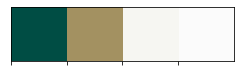

In [6]:
sns.palplot(['#004D44','#A39161','#F6F6F2','#FBFBFB'])

<a id="2.1"></a>
## <p style="font-size:100%; text-align:left; color:#444444;">Percentage of captured birds with avian flu</p>

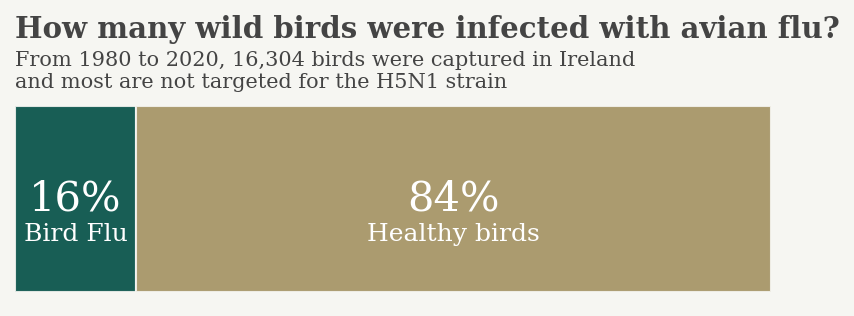

In [78]:
x=bird_flu.groupby(['target_H5_HPAI'])['target_H5_HPAI'].count()
y=len(bird_flu)
r=((x/y)).round(2)
ratio = pd.DataFrame(r).T

fig, ax = plt.subplots(1,1,figsize=(6.5, 1.8),dpi=150)
background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color) 

ax.barh(ratio.index, ratio[1.0], color='#004D44', alpha=0.9, ec=background_color, label='Infected Birds')
ax.barh(ratio.index, ratio[0.0], left=ratio[1.0], color='#A39161', alpha=0.9,ec=background_color, label='Healthy Birds')

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.legend().set_visible(False)
for s in ['top', 'left', 'right', 'bottom']:
    ax.spines[s].set_visible(False)

for i in ratio.index:
    ax.annotate(f"{int(ratio[1.0][i]*100)}%", xy=(ratio[1.0][i]/2, i),va = 'center', ha='center',fontsize=20, fontweight='light', fontfamily='serif',color='white')
    ax.annotate("Bird Flu", xy=(ratio[1.0][i]/2, -0.15),va = 'center', ha='center',fontsize=12, fontweight='light', fontfamily='serif',color='white')

for i in ratio.index:
    ax.annotate(f"{int(ratio[0.0][i]*100)}%", xy=(ratio[1.0][i]+ratio[0.0][i]/2, i),va = 'center', ha='center',fontsize=20, fontweight='light', fontfamily='serif',color='white')
    ax.annotate("Healthy birds", xy=(ratio[1.0][i]+ratio[0.0][i]/2, -0.15),va = 'center', ha='center',fontsize=12, fontweight='light', fontfamily='serif',color='white')

subtitle = 'From 1980 to 2020, {:,} birds were captured in Ireland \nand most are not targeted for the H5N1 strain'.format(y)
fig.text(0.125,1.1,'How many wild birds were infected with avian flu?', fontfamily='serif',fontsize=14, fontweight='bold', color='#444444')
fig.text(0.125,0.915,subtitle,fontfamily='serif',fontsize=10, color='#444444')  
plt.show()

In [8]:
grouped_scientific_name = pd.DataFrame({'count' : bird_flu.groupby(['Scientific_Name'])['Scientific_Name'].size()}).reset_index()
grouped_common_name = pd.DataFrame({'count' : bird_flu.groupby(['Common_Name'])['Common_Name'].size()}).reset_index()
grouped_parent_species = pd.DataFrame({'count' : bird_flu.groupby(['Parent_Species'])['Parent_Species'].size()}).reset_index()

In [9]:
print("There are {} wild bird species present and {} parent species.".format(len(grouped_common_name), len(grouped_parent_species)))

There are 410 wild bird species present and 338 parent species.


In [10]:
infected_birds = bird_flu[bird_flu['target_H5_HPAI'] == 1]
top_infected_counties = infected_birds.groupby('County').size().sort_values(ascending=False)[:10]

<a id="2.2"></a>
## <p style="font-size:100%; text-align:left; color:#444444;">Counties with the highest Bird Flu occurences</p>

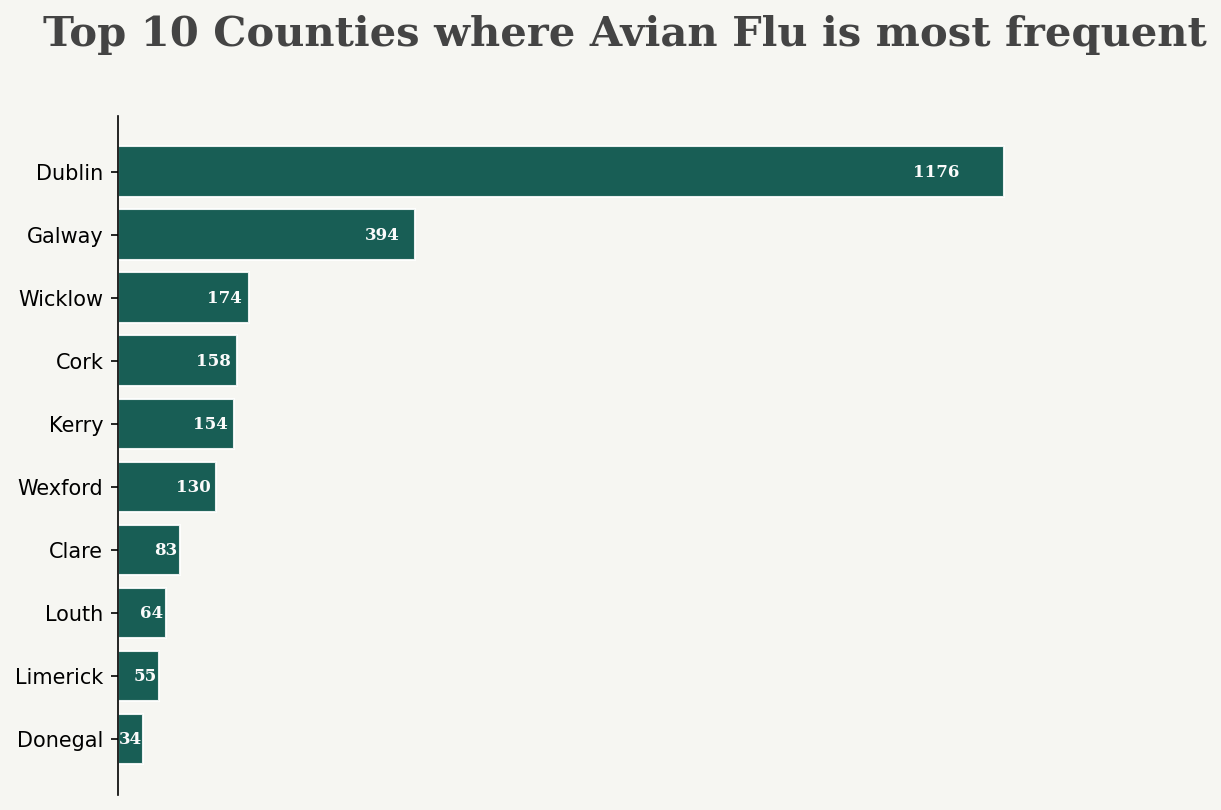

In [11]:
fig, ax = plt.subplots(1,1, figsize=(8, 6),dpi=150)

background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color) # figure background color
ax.set_facecolor(background_color) 

# Top infected locations 
data = top_infected_counties

color_map = ['#004D44' for _ in range(len(data))]
ax.barh(data.index, data, 
       edgecolor='white',color=color_map, alpha=0.9)

# diff color text
for i in range(0,10):
    ax.annotate(list(data)[i], 
                   xy=(data[i]-(data[i]*0.05), i), 
                   va = 'center', ha='right', fontweight='bold',fontfamily='serif',fontsize=8, color='#FBFBFB')

ax.axes.get_xaxis().set_ticks([])
ax.invert_yaxis()

for s in ['top', 'bottom', 'right']:
    ax.spines[s].set_visible(False)
    
ax.text(-100,-2.0,'Top 10 Counties where Avian Flu is most frequent',
        fontfamily='serif',fontsize=20,fontweight='bold',color='#444444')

plt.show()

<a id="2.3"></a>
## <p style="font-size:100%; text-align:left; color:#444444;">What locations have registered the highest number of wild birds with avian flu?</p>

In [12]:
top_infected_locations = infected_birds.groupby('Locality').size().sort_values(ascending=False)[:10]

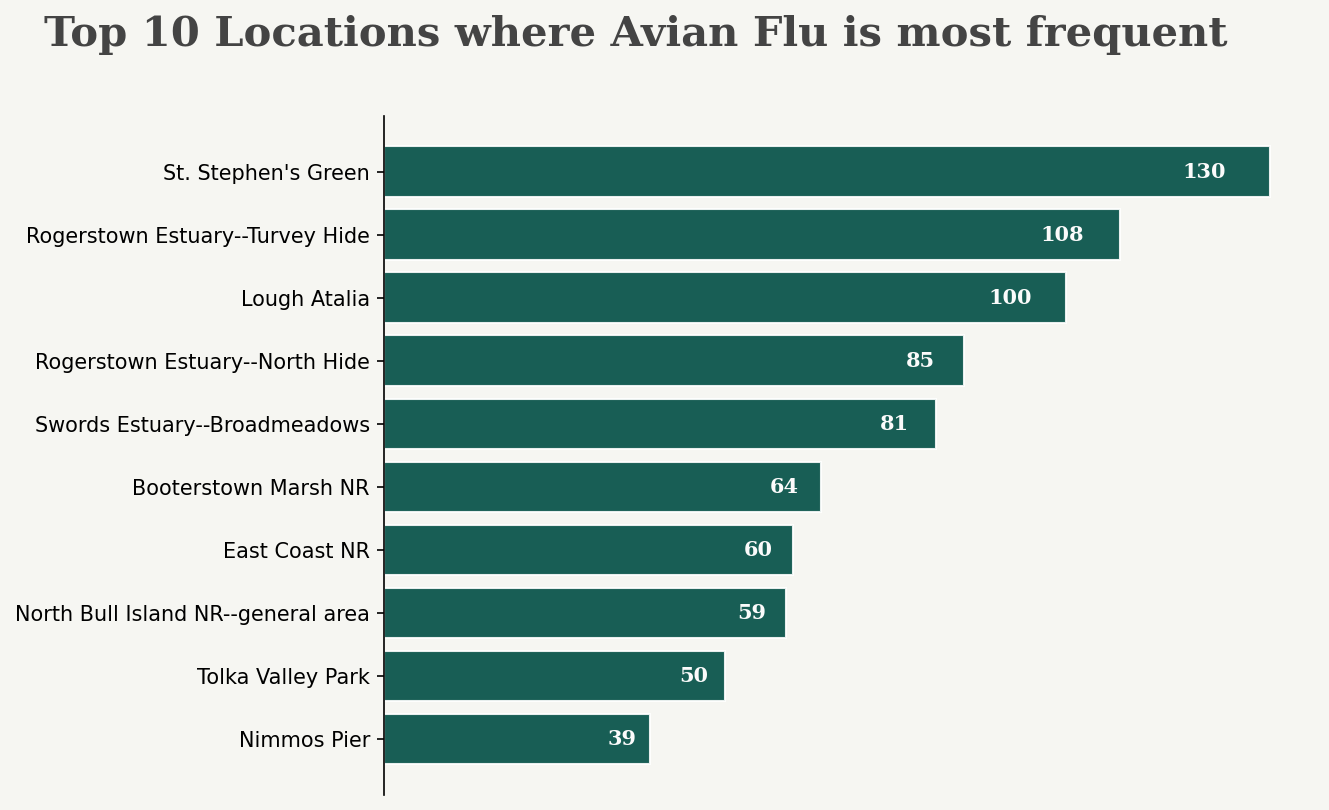

In [13]:
fig, ax = plt.subplots(1,1, figsize=(8, 6),dpi=150)

background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color) # figure background color
ax.set_facecolor(background_color) 

# Top infected locations 
data = top_infected_locations

color_map = ['#004D44' for _ in range(len(data))]
ax.barh(data.index, data, 
       edgecolor='white',color=color_map, alpha=0.9)

# diff color text
for i in range(0,10):
    ax.annotate(list(data)[i], 
                   xy=(data[i]-(data[i]*0.05), i), 
                   va = 'center', ha='right', fontweight='bold',fontfamily='serif',fontsize=10, color='#FBFBFB')

ax.axes.get_xaxis().set_ticks([])
ax.invert_yaxis()

for s in ['top', 'bottom', 'right']:
    ax.spines[s].set_visible(False)
    
ax.text(-50,-2.0,'Top 10 Locations where Avian Flu is most frequent',
        fontfamily='serif',fontsize=20,fontweight='bold',color='#444444')

plt.show()

<a id="2.4"></a>
## <p style="font-size:100%; text-align:left; color:#444444;">In which months are birds with Bird Flu more frequent?</p>

In [14]:
def monthFormatter(month):
    """
    Take the representative number of a month and return its abbreviation
    """
    switcher = {
        1: "Jan",
        2: "Feb",
        3: "Mar",
        4: "Apr",
        5: "May",
        6: "Jun",
        7: "Jul",
        8: "Aug",
        9: "Sep",
        10: "Oct",
        11: "Nov",
        12: "Dec"
    }
    
    return switcher.get(month, "Invalid month")

In [15]:
infected_bymonth = infected_birds.groupby('Month').size().sort_index(ascending=True)

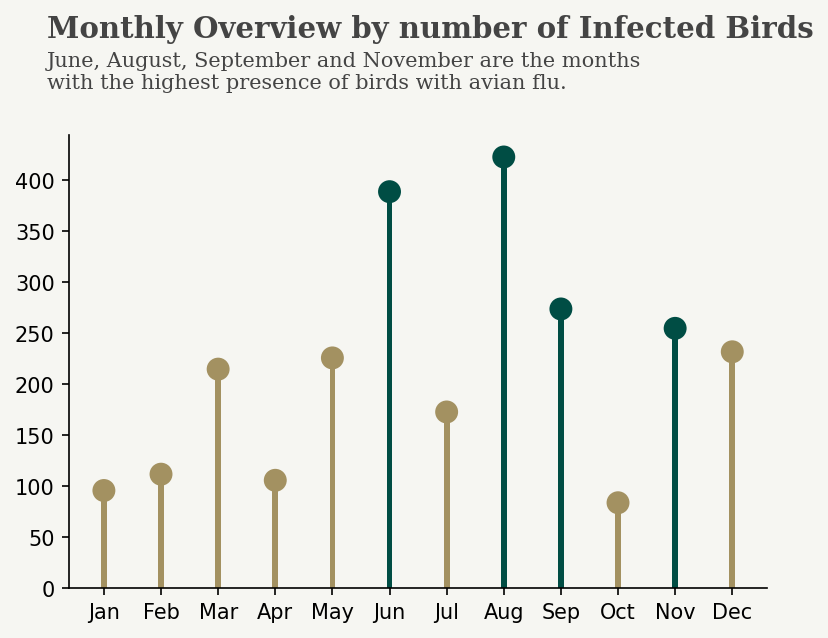

In [16]:
fig, ax = plt.subplots(1,1, figsize=(6, 4),dpi=150)

background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color) # figure background color
ax.set_facecolor(background_color)
color_map = ['#004D44' if value > 250 else '#A39161' for index, value in infected_bymonth.items()]

# MONTH OVERVIEW
ax.bar(np.arange(len(infected_bymonth.index)), infected_bymonth, zorder=1, color=color_map, width=0.1)
ax.scatter(np.arange(len(infected_bymonth.index)), infected_bymonth, zorder=1,s=100, color=color_map)

ax.set_xticks(np.arange(len(infected_bymonth.index)))
ax.set_xticklabels(map(monthFormatter,list(infected_bymonth.index)),rotation=0)

ax.text(-1, 540, 'Monthly Overview by number of Infected Birds', fontsize=14, fontweight='bold', 
        fontfamily='serif', color='#444444')
ax.text(-1, 490, 
        'June, August, September and November are the months \nwith the highest presence of birds with avian flu.', 
        fontfamily='serif',fontsize=10, color='#444444')  

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

plt.show()

<a id="2.5"></a>
## <p style="font-size:100%; text-align:left; color:#444444;">Wild birds targeted with avian flu have increased or have decreased on the last decade?</p>

In [17]:
infected_birds_byYear = infected_birds.groupby('Year').size().sort_index(ascending=True).filter(items=range(2010,2021), axis=0)

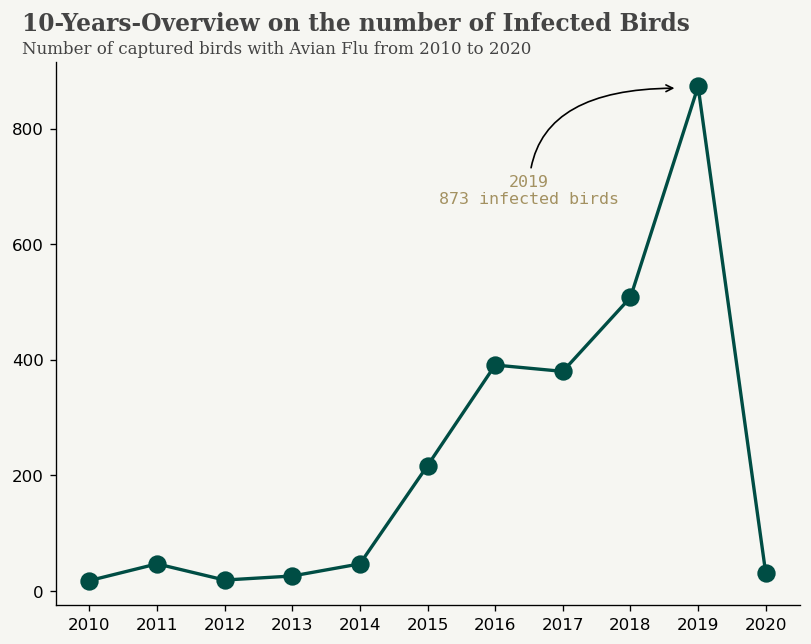

In [79]:
fig, ax = plt.subplots(1,1, figsize=(8, 6),dpi=120)
background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color) # figure background color

infected_birds_byYear.index = infected_birds_byYear.index.map(str)
ax.set_facecolor(background_color)
ax.plot(infected_birds_byYear.index, infected_birds_byYear, color='#004D44', linewidth=2)
ax.set_xticks(np.arange(len(infected_birds_byYear)))
ax.set_xticklabels(infected_birds_byYear.index,rotation=0)

ax.scatter(infected_birds_byYear.index, infected_birds_byYear, zorder=1,s=100, color='#004D44')

plt.annotate('2019\n%d infected birds'%infected_birds_byYear['2019'], xy=(8.7, 870), xytext=(6.5, 670), 
             arrowprops=dict(facecolor='#444444',arrowstyle="->",connectionstyle="angle3,angleA=90,angleB=0"), 
             fontsize=10,fontfamily='monospace',ha='center', color='#A39161')

for s in ["right", "top"]:
    ax.spines[s].set_visible(False)
    
ax.text(-1, 970, '10-Years-Overview on the number of Infected Birds', fontsize=14, 
         fontweight='bold', fontfamily='serif', color='#444444')
ax.text(-1, 930, 'Number of captured birds with Avian Flu from 2010 to 2020', fontsize=10, 
        fontfamily='serif', color='#444444')

plt.xticks(rotation=0)
plt.show()

## Ordnance Survey *Ireland* (OSi). - Ireland’s National Mapping Agency

>https://data-osi.opendata.arcgis.com/

## Administrative Areas - OSi National Statutory Boundaries

https://data-osi.opendata.arcgis.com/datasets/0d5984f732c54246bd087768223c92eb_0?geometry=-7.002%2C53.175%2C-5.684%2C53.319

In [19]:
admin_areas_json = 'data/Administrative_Areas_Ireland.json'
url_geoJSON = 'https://opendata.arcgis.com/datasets/0d5984f732c54246bd087768223c92eb_0.geojson'

In [20]:
try:
    f = open(admin_areas_json, 'rb')
    with f:
        admin_areas = gpd.read_file(f, driver='GeoJSON')
        
except FileNotFoundError:
    print("File {} does not exist... creating a new one from API".format(admin_areas_json))

    # GeoJSON API
    admin_areas = gpd.read_file(url_geoJSON, driver='GeoJSON')
    
    # Saving the data downloaded to a local json file
    admin_areas.to_file(admin_areas_json, driver='GeoJSON')

In [21]:
avian_flu = infected_birds.copy()
avian_flu['geometry'] = None

for index, row in avian_flu.iterrows():
    avian_flu.loc[index, 'geometry'] = Point(row.Longitude, row.Latitude)

>https://epsg.io/29902

In [102]:
gdf_infected_birds = gpd.GeoDataFrame(avian_flu, geometry='geometry').set_crs(epsg=29902, inplace=True)

# Map

In [103]:
mean_latitude = gdf_infected_birds['Latitude'].mean()
mean_longitude = gdf_infected_birds['Longitude'].mean()

fmap = folium.Map(location=[mean_latitude, mean_longitude], tiles="Stamen Terrain", zoom_start=7)

mc = FastMarkerCluster(gdf_infected_birds[['Latitude', 'Longitude']])

fmap.add_child(mc)
fmap.save('./maps/avian_flu_map_simpleV.html')
fmap

## Adding Limits to Counties

In [24]:
mean_latitude = gdf_infected_birds['Latitude'].mean()
mean_longitude = gdf_infected_birds['Longitude'].mean()

In [25]:
#tiles="Stamen Terrain"
fmap = folium.Map(location=[mean_latitude, mean_longitude], tiles="cartodbpositron", zoom_start=7)

limits = folium.features.GeoJson(admin_areas,
                                style_function = lambda feature: {
                                    'color': 'black',
                                    'weight': 1,
                                    'fillOpacity': 0.0
                                })

fmap.add_child(limits)
mc = FastMarkerCluster(gdf_infected_birds[['Latitude', 'Longitude']])
fmap.add_child(mc)
# saving Map to html file
fmap.save('maps/avian_flu_map_simpleV.html')

## HeatMap

In [49]:
fmap = folium.Map(location=[mean_latitude, mean_longitude], tiles="cartodbpositron", zoom_start=7)

heat_map = HeatMap(gdf_infected_birds[['Latitude', 'Longitude']])
fmap.add_child(heat_map)

# saving Map to html file
fmap.save('maps/heatmap_avian_flu.html')

## Adding info into the Map

In [27]:
# adding Count of occurence on each Administrative Area
for index, area in admin_areas.iterrows():
    count_infected_birds = len(gdf_infected_birds[gdf_infected_birds.intersects(area.geometry)])
    admin_areas.loc[index, 'INFECTED_BIRDS'] = count_infected_birds

In [64]:
%%time

fmap = folium.Map(
                    location=[mean_latitude, mean_longitude],
                    tiles='Cartodb Positron',
                    zoom_start=7
                )

for _, county in admin_areas.iterrows():
    
    counties_geojson = folium.features.GeoJson(county.geometry,
                                style_function = lambda feature: {
                                    'color': 'black',
                                    'weight': 1,
                                    'fillOpacity': 0.0
                                })
    
    popup = folium.Popup("""
                            County: {} <br>
                            Birds with Avian Flu: {}
                            """.format(county.ENGLISH, str(int(county.INFECTED_BIRDS))), max_width=300)
    
    popup.add_to(counties_geojson)
    counties_geojson.add_to(fmap)
    
marker_cluster = MarkerCluster(
    overlay=True,
    control=False,
    icon_create_function=None
)

for i in range(0,len(gdf_infected_birds)):
    
    custom_popup = """
        <h4>{}</h4>
        <b>Parent Species:</b> {}<br>
        <b>Captured on:</b> {}<br>
        <b>Locality:</b> {}<br>
    """.format(gdf_infected_birds.iloc[i]['Common_Name'],
              gdf_infected_birds.iloc[i]['Parent_Species'],
              gdf_infected_birds.iloc[i]['Date'],
              gdf_infected_birds.iloc[i]['Locality'])
    
    marker = folium.Marker(location=[gdf_infected_birds.iloc[i]['Latitude'], gdf_infected_birds.iloc[i]['Longitude']])
    folium.Popup(custom_popup, max_width=300).add_to(marker)
    marker_cluster.add_child(marker)

marker_cluster.add_to(fmap)
folium.LayerControl().add_to(fmap)
fmap.save('maps/avian_flu_map.html')

CPU times: user 22.6 s, sys: 1.97 s, total: 24.5 s
Wall time: 24.9 s
